# Introduction

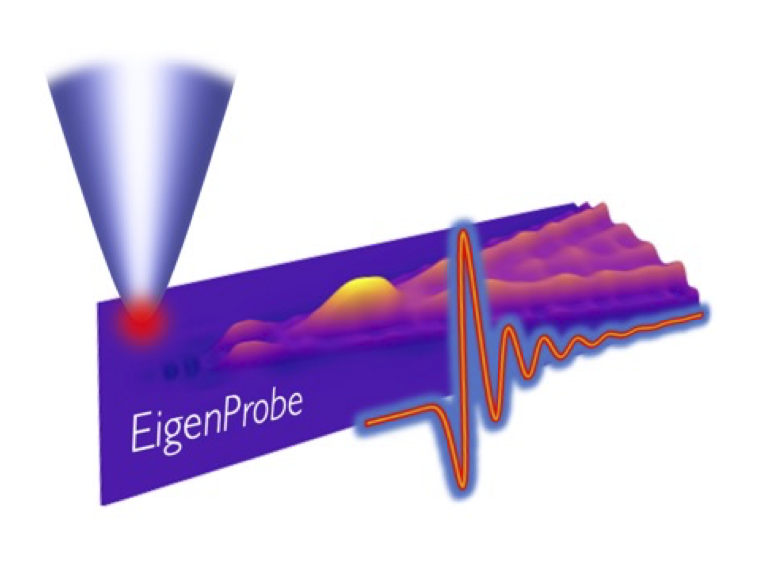

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

Here we will [TODO]

# Imports

## General Imports

In [1]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload
import numpy as np

/usr/local/Cellar/micromamba/2.8.1/envs/EigenProbe/lib/python3.9/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Numba 0.54.1 is known to work well with this package.
Numba version that was imported: 0.54.1
Numpy 1.20.3 is known to work well with this package.
Numpy version that was imported: 1.20.3


## Specialized Imports

In [2]:
from EigenProbe.common.baseclasses import AWA 
from EigenProbe.common.misc import flatten
from EigenProbe.common import numerical_recipes as numrec

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

# It is known that `sympy` wraps `numpy` universal functions in a way that conflicts with `numba`.  Avoid importing `Materials` until necessary.
from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
from NearFieldOptics.Materials import material_types,TransferMatrixMedia

<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

## EigenProbe Imports 

In [3]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Load probe and spectroscopies

In [4]:
a_nm=20
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle=21
geometry='hyperboloid'

Nnodes=244

probe_name = '%s_a=%inm_taper=%i_L=%imicrons_Nnodes=%i'%(geometry.capitalize(),a_nm,taper_angle,L_microns,Nnodes)
#probe_name='hyperboloid'
#probe_name = 'Cone_a=20nm_taper=21_L=23microns_Nnodes=488'
#probe_name = 'Cone_a=20nm_taper=21_L=23microns_Nnodes=244'
P = EP.load(probe_name,EP.Probe)
a = P.get_a()

ProbeGapSpectroscopy = EP.load(P, PS.ProbeGapSpectroscopyParallel, overwrite_probe=True)

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperbo

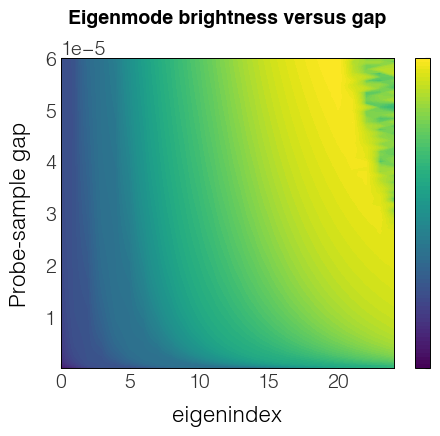

In [90]:
vs = ProbeGapSpectroscopy.get_eigenbrightness_AWA()
np.abs(vs).plot(plotter=plt.contourf,log_scale=True)
plt.ylabel('Probe-sample gap')
plt.title('Eigenmode brightness versus gap')

Nmodes_compute = len(vs) # This is the number of eigenmodes available in the ProbeSpectroscopy
gapmin = vs.axes[1].min()

#  Parameters of simulations

In [62]:
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 4*a_nm # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
kappa_max=None #20/P.get_a() # Largest value of in-plane momentum (in Probe units) to use for internal momentum quadrature with Fresnel coefficient
Nkappas = 244*2 # Number of momentum quadrature points to use by default
Ngaps = 24 # Number of probe-sample gap nodesto use for computing demodulated scattering

kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes_compute)

# Build Calculators

In [96]:
# Load or compute an `EncodedEigenfields` instance associated with Probe `P`
save = True
overwrite=True
recompute = True

try:
    if recompute: raise OSError
    EE = EP.load(probe_name,PS.EncodedEigenfields)
except OSError: # didn't find it
    print('Encoding %i eigenfields...'%Nmodes_compute) 
    gap0 = gapmin #P.get_a()/20 # The smaller, the better
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=Nmodes_compute,
                                kappa_min=None, kappa_max=kappa_max,
                                Nkappas=244*4, qquadrature=PS.numrec.GL)
    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save encoded eigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')


# Load or compute an `InvertibleEigenfields` instance associated with Probe `P`
save = True
overwrite=False
recompute = False

try:
    if recompute: raise OSError
    IE = EP.load(probe_name,PS.InvertibleEigenfields)
except OSError: # didn't find it
    print('Making %i eigenfields invertible...'%Nmodes_compute) 
    IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=Nmodes_compute,
                                           interpolation='linear')
    if save:
        try: EP.save(IE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save invertible eigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Encoding 25 eigenfields...
<ProbeCavityEigenfields.ProbeSpectroscopy.EncodedEigenfields.__init__>:
	Encoding 25 eigenfields to gap=4.2e-08 across 245 gap values from gap=(4.2e-08 to 6e-05)...
<ProbeCavityEigenfields.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.get_probe_at_coord>:
	Updating eigenrhos to coordinate 4.19E-08...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
Successfully saved to file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"!
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_

# Compare predictions of demodulated s-SNOM signal for identical values of (local) reflectance $\beta$

In [97]:
# Evaluate at a select of local reflectance values where calculation is most difficult, very close to the real line
Q = 10 # "quality factor" of the reflectance, its inverse is a way to set absorptivity of the reflectance
betas = np.linspace(-10,10,21)*(1+1j/Q)
betas = betas.real + 1j*np.abs(betas.imag)

# Frequency values to associate with the reflectance values; these are ad hoc but allow plotting `betas`-dependent quantities each as a spectrum 
freqs_beta = np.linspace(500,1000,len(betas))
betas = AWA(betas,axes=[freqs_beta])
rp = lambda freq_wn,q:  betas.interpolate_axis(freq_wn,axis=0) # "wrap" the beta values in a Fresnel coefficient that can be queried for them

# Predict a demodulated scattering spectrum with `InvertibleEigenfields` instance
test_spectrum_IE_beta = IE.getNormalizedSignal(freqs_wn=freqs_beta,
                                         beta=betas,beta_norm=[1]*len(betas),
                                         **kwargs)

# Predict the same spectrum with `EncodedEigenfields` instance
test_spectrum_EE_beta = EE.getNormalizedSignal(freqs_wn=freqs_beta,
                                           rp=rp,rp_norm=M.Au.reflection_p,
                                           **kwargs)

# Predict the same spectrum with the `Probe` object itself
#test_spectrum_P_beta = P.getNormalizedSignal(freqs_wn=freqs_beta,
#                                         rp=rp,rp_norm=M.Au.reflection_p,
#                                         kappa_max=kappa_max,
#                                        Nkappas=Nkappas,
#                                         **kwargs)

amplitude= 5.333333333333334e-06
gapmin= 2e-07
	Computing at freq=5.001E+02...
	Computing at freq=5.251E+02...
	Computing at freq=5.501E+02...
	Computing at freq=5.751E+02...
	Computing at freq=6.001E+02...
	Computing at freq=6.251E+02...
	Computing at freq=6.501E+02...
	Computing at freq=6.751E+02...
	Computing at freq=7.001E+02...
	Computing at freq=7.251E+02...
	Computing at freq=7.501E+02...
	Computing at freq=7.751E+02...
	Computing at freq=8.001E+02...
	Computing at freq=8.251E+02...
	Computing at freq=8.501E+02...
	Computing at freq=8.751E+02...
	Computing at freq=9.001E+02...
	Computing at freq=9.251E+02...
	Computing at freq=9.501E+02...
	Computing at freq=9.751E+02...
	Computing at freq=1.000E+03...
<ProbeCavityEigenfields.ProbeSpectroscopy.EncodedEigenfields.EradSpectrumDemodulated>:
	Demodulating...
		Time elapsed: 0.23118901252746582
	Computing at freq=7.501E+02...
<ProbeCavityEigenfields.ProbeSpectroscopy.EncodedEigenfields.EradSpectrumDemodulated>:
	Demodulating...
		Tim

Text(0.5, 1.0, 'Demodulated scattering prediction')

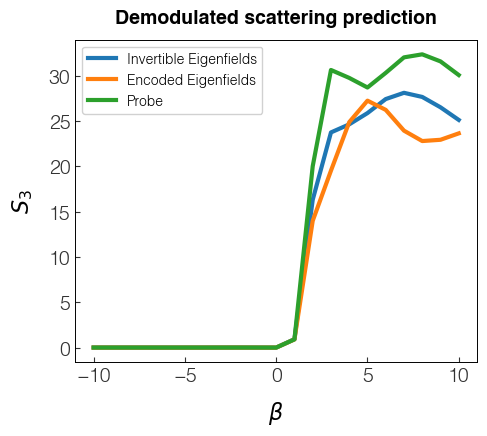

In [98]:
# All calculation methods are intended to be equivalent, so predictions should match

harmonic=3
plt.plot(betas,np.abs(test_spectrum_IE_beta['Sn_norm'][harmonic]),label='Invertible Eigenfields')
plt.plot(betas,np.abs(test_spectrum_EE_beta['Sn_norm'][harmonic]),label='Encoded Eigenfields')
plt.plot(betas,np.abs(test_spectrum_P_beta['Sn_norm'][harmonic]),label='Probe')

plt.legend()
plt.xlabel(r'$\beta$')
plt.ylabel(r'$S_%i$'%harmonic)
plt.title('Demodulated scattering prediction')

## Compare spectra predicted for SiC using local reflectance

In [104]:
freqs_wn = np.linspace(800,1000,50) # Energies spanning SiC phonon

# Define the local reflectance of SiC
material = M.SiC_6H
epss = material.epsilon(freqs_wn) 
beta = (epss-1)/(epss+1)
beta_norm=1

test_spectrum_IE_mat = IE.getNormalizedSignal(freqs_wn=freqs_wn,Nmodes=Nmodes_compute,
                                         beta=beta,beta_norm=[beta_norm]*len(beta),
                                         **kwargs)

qbig = 1/20e-7 # Large momentum value lying squarely in the quasi-static regime
get_beta = lambda freq,q: np.squeeze(material.reflection_p(freq,qbig)) # Define an effective Fresnel coefficient that only evaluates local reflectance

test_spectrum_EE_mat = EE.getNormalizedSignal(freqs_wn=freqs_wn,Nmodes=Nmodes_compute,
                                                     rp=get_beta,rp_norm=M.Au.reflection_p,
                                                     **kwargs)

test_spectrum_P_mat = P.getNormalizedSignal(freqs_wn=freqs_wn,Nmodes=Nmodes_compute,
                                         rp=get_beta,rp_norm=M.Au.reflection_p,
                                         **kwargs)

amplitude= 5.333333333333334e-06
gapmin= 2e-07
	Computing at freq=8.001E+02...
	Computing at freq=8.042E+02...
	Computing at freq=8.083E+02...
	Computing at freq=8.124E+02...
	Computing at freq=8.164E+02...
	Computing at freq=8.205E+02...
	Computing at freq=8.246E+02...
	Computing at freq=8.287E+02...
	Computing at freq=8.328E+02...
	Computing at freq=8.368E+02...
	Computing at freq=8.409E+02...
	Computing at freq=8.450E+02...
	Computing at freq=8.491E+02...
	Computing at freq=8.532E+02...
	Computing at freq=8.573E+02...
	Computing at freq=8.613E+02...
	Computing at freq=8.654E+02...
	Computing at freq=8.695E+02...
	Computing at freq=8.736E+02...
	Computing at freq=8.777E+02...
	Computing at freq=8.817E+02...
	Computing at freq=8.858E+02...
	Computing at freq=8.899E+02...
	Computing at freq=8.940E+02...
	Computing at freq=8.981E+02...
	Computing at freq=9.022E+02...
	Computing at freq=9.062E+02...
	Computing at freq=9.103E+02...
	Computing at freq=9.144E+02...
	Computing at freq=9.185E

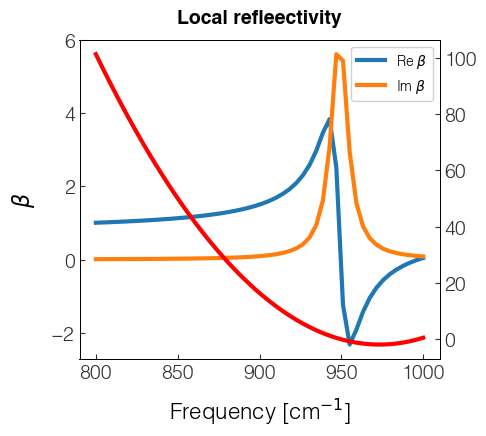

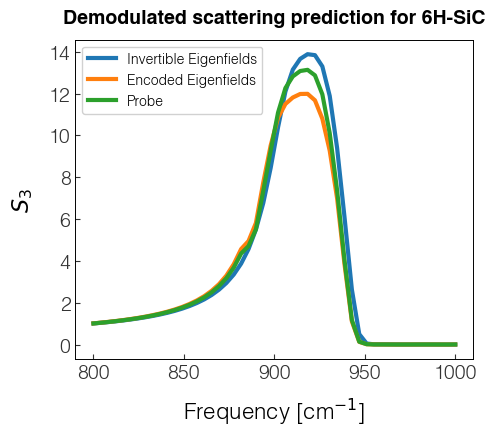

In [109]:
plt.figure()

plt.plot(freqs_wn,beta.real,label=r'Re $\beta$')
plt.plot(freqs_wn,beta.imag,label=r'Im $\beta$')
plt.title('Local refleectivity')
plt.xlabel(r'Frequency [cm$^{-1}$]')
plt.ylabel(r'$\beta$')
plt.legend()

plt.figure()

harmonic=3
plt.plot(freqs_wn,np.abs(test_spectrum_IE_mat['Sn_norm'][harmonic]),label='Invertible Eigenfields')
plt.plot(freqs_wn,np.abs(test_spectrum_EE_mat['Sn_norm'][harmonic]),label='Encoded Eigenfields')
plt.plot(freqs_wn,np.abs(test_spectrum_P_mat['Sn_norm'][harmonic]),label='Probe')

plt.title('Demodulated scattering prediction for 6H-SiC')
plt.xlabel(r'Frequency [cm$^{-1}$]')
plt.ylabel(r'$S_%i$'%harmonic)
plt.legend()

# Check convergence for each calculation method for $\beta$ in active coupling regime

## Direct calculation

### Ngaps convergence

In [110]:
all_Ngaps = np.linspace(1,4,4)*12
Nkappas = 122
all_signals=[]
for i,Ngaps in enumerate(all_Ngaps):

    print('Computing convergence round %i of %i'%(i+1, len(all_Ngaps)))

    signals_direct = P.getNormalizedSignal(freqs_beta,rp,
                                        a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                        Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                        rp_norm = M.Au.reflection_p,
                                        Nkappas=Nkappas,kappa_max=kappa_max)
    
    all_signals.append(signals_direct)

Computing convergence round 1 of 4
amplitude= 4e-06
gapmin= 2e-07
<EigenProbe.Probe.EradVsGap>:
	Computing response for 12 gaps at freq=500.0647045981104...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 12 gaps at freq=525.0679398280158...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 12 gaps at freq=550.0711750579214...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 12 gaps at freq=575.0744102878269...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response 

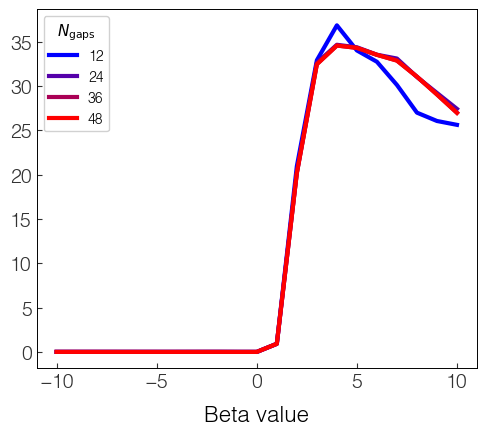

In [111]:
harmonic=3
cs = bluered_colors(len(all_Ngaps))
for i,Ngaps in enumerate(all_Ngaps):
    signals_direct =all_signals[i]
    plt.plot(betas, np.abs(signals_direct['Sn_norm'][harmonic]),
                          color=next(cs),label='%i'%Ngaps)
plt.xlabel('Beta value')
plt.legend(title=r'$N_\mathrm{gaps}$')

### kappa quadrature convergence

In [112]:
all_Nkappas = [244/2,244,244*2]
Ngaps = 24
freqs_wn = np.linspace(800,1000,30)
all_signals=[]
for i,Nkappas in enumerate(all_Nkappas):

    print('Computing convergence round %i of %i'%(i+1, len(all_Nkappas)))

    signals_direct = P.getNormalizedSignal(freqs_wn,rp=material.reflection_p,
                                        a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                        Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                        rp_norm = M.Au.reflection_p,
                                        Nkappas=Nkappas,kappa_max=kappa_max)
    all_signals.append(signals_direct)

Computing convergence round 1 of 3
amplitude= 4e-06
gapmin= 2e-07
<EigenProbe.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=800.1035273569765...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=807.0009715583298...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=813.8984157596831...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response for 24 gaps at freq=820.7958599610364...
<EigenProbe.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<EigenProbe.Probe.EradVsGap>:
	Computing response 

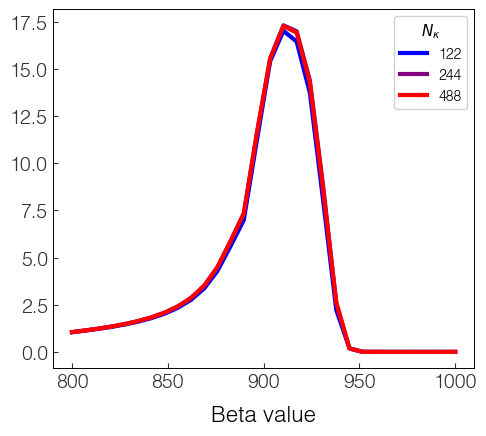

In [113]:
harmonic=3
cs = bluered_colors(len(all_Nkappas))
for i,Nkappas in enumerate(all_Nkappas):
    signals_direct =all_signals[i]
    plt.plot(freqs_wn, np.abs(signals_direct['Sn_norm'][harmonic]),
                          color=next(cs),label='%i'%Nkappas)
plt.xlabel('Beta value')
plt.legend(title=r'$N_\kappa$')

## Invertible Eigenfields - Ngaps convergence

Because this calculation method cannot consider nonlocal reflectivity, there is no convergence with respect to q-values to consider.

In [114]:
all_Ngaps = np.linspace(1,4,6)*12
all_signals=[]
for i,Ngaps in enumerate(all_Ngaps):
    print('Computing convergence round %i of %i'%(i+1, len(all_Ngaps)))

    signals_IE = IE.getNormalizedSignal(betas,
                                        a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                        Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                        beta_norm = [1]*len(betas),
                                        max_harmonic=5,
                                        Nmodes=None)
    all_signals.append(signals_IE)

Computing convergence round 1 of 6
amplitude= 4e-06
gapmin= 2e-07
Computing convergence round 2 of 6
amplitude= 4e-06
gapmin= 2e-07
Computing convergence round 3 of 6
amplitude= 4e-06
gapmin= 2e-07
Computing convergence round 4 of 6
amplitude= 4e-06
gapmin= 2e-07
Computing convergence round 5 of 6
amplitude= 4e-06
gapmin= 2e-07
Computing convergence round 6 of 6
amplitude= 4e-06
gapmin= 2e-07


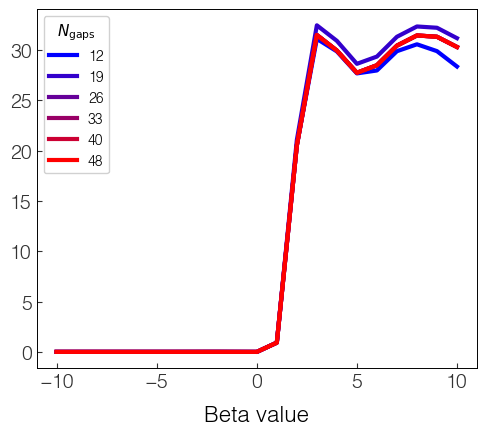

In [115]:
harmonic=3
cs = bluered_colors(len(all_Ngaps))
for i,Ngaps in enumerate(all_Ngaps):
    signals_IE =all_signals[i]
    plt.plot(betas, np.abs(signals_IE['Sn_norm'][harmonic]),
                          color=next(cs),label='%i'%Ngaps)
plt.xlabel('Beta value')
plt.legend(title=r'$N_\mathrm{gaps}$')

## Encoded Eigenfields - Ngaps convergence

Because this calculation method has already established a quadrature grid for q-values for nonlocal reflectance, there is no convergence with respect to q-values to consider.

In [116]:
all_Ngaps = np.linspace(1,4,6)*12
all_signals = []
for i,Ngaps in enumerate(all_Ngaps):

    print('Computing convergence round %i of %i'%(i+1, len(all_Ngaps)))

    signals_enc = EE.getNormalizedSignal(freqs_beta,rp,
                                        a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                        Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                        L_cm=24e-4,
                                        rp_norm = M.Au.reflection_p,
                                        norm_single_freq = True)
    all_signals.append(signals_enc)

Computing convergence round 1 of 6
	Computing at freq=5.001E+02...
	Computing at freq=5.251E+02...
	Computing at freq=5.501E+02...
	Computing at freq=5.751E+02...
	Computing at freq=6.001E+02...
	Computing at freq=6.251E+02...
	Computing at freq=6.501E+02...
	Computing at freq=6.751E+02...
	Computing at freq=7.001E+02...
	Computing at freq=7.251E+02...
	Computing at freq=7.501E+02...
	Computing at freq=7.751E+02...
	Computing at freq=8.001E+02...
	Computing at freq=8.251E+02...
	Computing at freq=8.501E+02...
	Computing at freq=8.751E+02...
	Computing at freq=9.001E+02...
	Computing at freq=9.251E+02...
	Computing at freq=9.501E+02...
	Computing at freq=9.751E+02...
	Computing at freq=1.000E+03...
<ProbeCavityEigenfields.ProbeSpectroscopy.EncodedEigenfields.EradSpectrumDemodulated>:
	Demodulating...
		Time elapsed: 0.10879778861999512
	Computing at freq=7.501E+02...
<ProbeCavityEigenfields.ProbeSpectroscopy.EncodedEigenfields.EradSpectrumDemodulated>:
	Demodulating...
		Time elapsed: 0

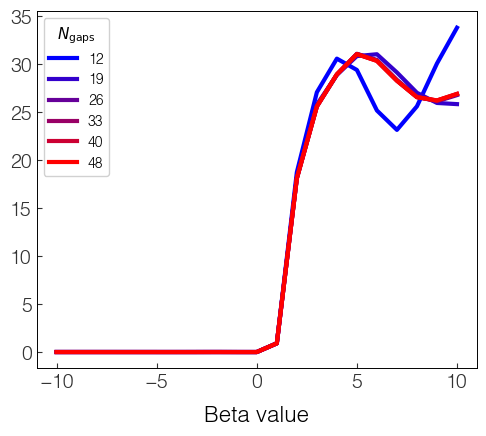

In [117]:
harmonic=3
cs = bluered_colors(len(all_Ngaps))
for i,Ngaps in enumerate(all_Ngaps):
    signals_enc =all_signals[i]
    plt.plot(betas, np.abs(signals_enc['Sn_norm'][harmonic]),
                          color=next(cs),label='%i'%Ngaps)
plt.xlabel('Beta value')
plt.legend(title=r'$N_\mathrm{gaps}$')

# Compute calibration curves for probe

In [145]:
amplitude_factors=np.linspace(.1,10,20)
gapmin_factors=np.linspace(.05,1,20)

Ngaps=24*2

all_s3s_si=[]
all_s2s_si=[]
all_s3s_au=[]
all_s2s_au=[]
for i,gapmin_factor in enumerate(gapmin_factors):
    gapmin_nm = a_nm*gapmin_factor

    these_s3s_si=[]
    these_s2s_si=[]
    these_s3s_au=[]
    these_s2s_au=[]
    
    for j,amp_factor in enumerate(amplitude_factors):
        print('Working on calculation %i of %i'%(j+1+i*len(amplitude_factors),
                                                 len(amplitude_factors)*len(gapmin_factors)))
        A_nm = a_nm*amp_factor
    
        signals_si = IE.getNormalizedSignal(M.Si.reflection_p(1000,q=1/10e-7),
                                            a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                            Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                            beta_norm = None,
                                            max_harmonic=5,
                                            Nmodes=None)
        signals_au = IE.getNormalizedSignal(1,
                                            a_nm=a_nm,amplitude_nm=A_nm,demod_order=5,
                                            Ngaps=Ngaps,gapmin_nm=gapmin_nm,
                                            beta_norm = None,
                                            max_harmonic=5,
                                            Nmodes=None)
        these_s3s_si.append(signals_si['Sn'][3])
        these_s2s_si.append(signals_si['Sn'][2])
        these_s3s_au.append(signals_au['Sn'][3])
        these_s2s_au.append(signals_au['Sn'][2])
        
    all_s3s_si.append(these_s3s_si)
    all_s2s_si.append(these_s2s_si)
    all_s3s_au.append(these_s3s_au)
    all_s2s_au.append(these_s2s_au)

Working on calculation 1 of 400
amplitude= 2e-07
gapmin= 1e-07
amplitude= 2e-07
gapmin= 1e-07
Working on calculation 2 of 400
amplitude= 1.2421052631578948e-06
gapmin= 1e-07
amplitude= 1.2421052631578948e-06
gapmin= 1e-07
Working on calculation 3 of 400
amplitude= 2.2842105263157895e-06
gapmin= 1e-07
amplitude= 2.2842105263157895e-06
gapmin= 1e-07
Working on calculation 4 of 400
amplitude= 3.3263157894736848e-06
gapmin= 1e-07
amplitude= 3.3263157894736848e-06
gapmin= 1e-07
Working on calculation 5 of 400
amplitude= 4.368421052631579e-06
gapmin= 1e-07
amplitude= 4.368421052631579e-06
gapmin= 1e-07
Working on calculation 6 of 400
amplitude= 5.4105263157894745e-06
gapmin= 1e-07
amplitude= 5.4105263157894745e-06
gapmin= 1e-07
Working on calculation 7 of 400
amplitude= 6.45263157894737e-06
gapmin= 1e-07
amplitude= 6.45263157894737e-06
gapmin= 1e-07
Working on calculation 8 of 400
amplitude= 7.494736842105264e-06
gapmin= 1e-07
amplitude= 7.494736842105264e-06
gapmin= 1e-07
Working on calcula

In [146]:
all_s3s_si = AWA(all_s3s_si,axes=[gapmin_factors,amplitude_factors],
                 axis_names=['gapmin / a','A/a'])
all_s2s_si = AWA(all_s2s_si,axes=[gapmin_factors,amplitude_factors],
                 axis_names=['gapmin / a','A/a'])
all_s3s_au = AWA(all_s3s_au,axes=[gapmin_factors,amplitude_factors],
                 axis_names=['gapmin / a','A/a'])
all_s2s_au = AWA(all_s2s_au,axes=[gapmin_factors,amplitude_factors],
                 axis_names=['gapmin / a','A/a'])

In [147]:
all_s3divs2s_au = all_s3s_au/all_s2s_au
all_s3divs2s_si = all_s3s_si/all_s2s_si
all_s3au_rel_s3si = all_s3s_au/all_s3s_si

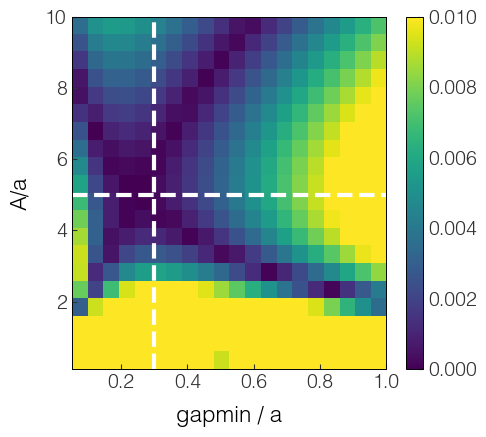

In [154]:
s3_au_rel_si_target  = 1.7
s3divs2_si_target= 0.35

diff1 = np.abs(all_s3au_rel_s3si)-s3_au_rel_si_target
diff2 = np.abs(all_s3divs2s_si)-s3divs2_si_target

np.abs(diff1*diff2).plot()
plt.clim(0,.01)

gapmin = .3
A = 5

plt.axhline(A,color='w',ls='--')
plt.axvline(gapmin,color='w',ls='--')